In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import os
import time
import re

import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    balanced_accuracy_score
)
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import torch
from tqdm import tqdm

from lightautoml.automl.presets.tabular_presets import TabularAutoML, TabularUtilizedAutoML
from lightautoml.dataset.roles import DatetimeRole
from lightautoml.tasks import Task

from lightautoml.report.report_deco import ReportDeco, ReportDecoUtilized
from lightautoml.addons.tabular_interpretation import SSWARM
import joblib

from config import (
    TAGS_EXCEL_PATH, DATA_CSV_PART1, DATA_CSV_PART2, TARGET_COL,
    load_tag_lists,
)


'nlp' extra dependency package 'fasttext-numpy2' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'transformers' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.


d:\DEV\Python_venv_hub\lightautoml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\DEV\Python_venv_hub\lightautoml_env\Lib\site-packages\lightautoml\ml_algo\dl_model.py:40: UserWarning: 'transformers' - package isn't installed
  warnings.warn("'transformers' - package isn't installed")
d:\DEV\Python_venv_hub\lightautoml_env\Lib\site-packages\lightautoml\text\embed.py:24: UserWarning: 'transformers' - package isn't installed
  warnings.warn("'transformers' - package isn't installed")
d:\DEV\Python_venv_hub\lightautoml_env\Lib\site-packages\lightautoml\text\dl_transformers.py:25: UserWarning: 'transformers' - package isn't installed
  warnings.warn("'transformers' - package isn't installed")


# Мега-аггрегаты HASHTAGS


In [2]:
# Молодежь (до 25)
youth_features = [
    "сегмент_молодежь",
    "сегмент молодежь риски",
    "core сегменты Подростки",
    "core сегменты Молодежь 18 21",
    "core сегменты Молодежь 22 24",
    "сегмент_light_МВС",
]

# Средний (25-35)
middle_features = [
    "сегмент_Активный_возраст",
    "core сегменты Становление",
    "Adult 25 44",
    "Женат",
    "Замужем",
    "Дети 1-3",
    "Дети 3-6",
    "дети 1 год",
    "дети 2 года",
    "дети 3 года",
    "дети 4 года",
    "дети 5 лет",
    "дети 6 лет",
    "look-alike есть дети от 0 до 3 лет",
    "look-alike есть дети от 4 до 7 лет",
    "Склонен получать детские пособия",
    "детские пособия выплата covid",
"Возраст от 30 до 40"
]

# Зрелые (35-50)
mature_features = [
    "бакет возраст 35-44",
    "core сегменты Расцвет",
    "core сегменты Зрелость",
    "Дети 6-13",
    "Дети 13-15",
    "Дети 17 лет",
    "дети 7 лет",
    "дети 8 лет",
    "дети 9 лет",
    "дети 10 лет",
    "дети 11 лет",
    "дети 12 лет",
    "дети 13 лет",
    "дети 14 лет",
    "дети 15 лет",
    "дети 16 лет",
    "look-alike есть дети от 8 до 12 лет",
    "look-alike есть дети от 13 до 16 лет",
    "Сервис sberads доход выше среднего",
    "родственники клиенты Сбера",
"Возраст от 40 до 55"
]

# Пожилой (50+)
elderly_features = [
    "сегмент_Пожилые",
    "бакет возраст 45-54",
    "Adult 45 64",
    "Склонен к использованию сервиса социальные зачисления",
"Возраст от 60 до 75"
]


# Автолюбитель (включая досуг с использованием автомобиля)
auto_lover = [
    "Склонен посещать картинг",
    "Склонен к покупке товаров для авто и мото",
    "Склонен пользоваться арендой авто",
    "Склонен к покупке запчастей",
    "Склонен оплачивать штрафы",
    "Планирует стать автомобилистом",
    "вождение",
    "Склонен к посещению автомоек",
    "Склонен к оплате парковки",
    "Склонен к покупке товаров и услуг для нового авто",
    "Автовладелец",
    "Склонен совершать покупки в АЗС",
    "Привычка пользоваться платной дорогой",
    "Склонен к покупке авто в салонах",
    "Склонен покупать товары для охоты и рыбалки",
    "Склонен покупать товары для охоты",
    "Склонен покупать товары для рыбалки",
    "Склонен пользоваться каршерингом",
    "Склонен пользоваться каршерингом преимущественно",
    "Склонен пользоваться каршерингом редко",
    "Склонен пользоваться каршерингом часто",
    "Склонен пользоваться каршерингом ЯндексДрайв",
    "Склонен пользоваться каршерингом Руссия",
    "Склонен пользоваться каршерингом BelkaCar",
    "Склонен пользоваться каршерингом Делимобиль",
    "Склонен пользоваться каршерингом Ситидрайв",
    "Склонен пользоваться каршерингом Bi-Bi Car",
    "Склонен пользоваться каршерингом Cars7",
    "Склонен пользоваться каршерингом VoronaCar",
    "Склонен регулярно пользоваться каршерингом Руссия",
    "Склонен регулярно пользоваться каршерингом Делимобиль",
    "Склонен регулярно пользоваться каршерингом YouDrive",
    "Привычка посещать автомобильный портал СберАвто",
    "Склонен совершать покупки в АЗС Shell",
    "Склонен совершать покупки в АЗС Газпром",
    "Склонен совершать покупки в АЗС Трасса",
    "Склонен совершать покупки в Газпромнефть",
    "Склонен совершать покупки в Лукойл",
    "Склонен совершать покупки в Нефтьмагистраль",
    "Склонен совершать покупки в Роснефть",
    "Склонен совершать покупки в ТНК",
    "Склонен совершать покупки в ЯндексЗаправки",
    "Склонен пользоваться шиномонтажом",
    "Привычка покупать запчасти в Авторусь",
    "Привычка покупать запчасти в Автомаг",
    "Склонен к покупке запчастей в Exist.ru",
    "Склонен пользоваться диагностикой проверкой авто",
    "Привычка покупать запчасти в Би-Би",
    "Привычка пользоваться парковкой днем",
    "Привычка пользоваться парковкой утром",
    "Привычка пользоваться парковкой ночью",
    "Привычка пользоваться парковкой вечером",
    "Привычка пользоваться парковкой по выходным",
    "Привычка пользоваться парковкой по будням",
    "Склонен к покупке автомасел",
    "Склонен к покупке автохимии",
    "Склонен оплачивать штрафы ГИБДД",
    "Готовится к экзаменам по вождению авто",
    "Жизненные ситуации застраховать автомобиль",
    "Жизненные ситуации купить собственное авто",
    "Жизненные ситуации обслуживать авто",
    "водит машину по будням",
    "водит машину по выходным",
"Склонен к активному досугу",
"Интерес к развлечениям вне дома",
    "Склонен поесть вне дома выход out ресторан",
    "Склонен поесть вне дома выход out мероприятие"

]

# Не_автолюбитель (общественный транспорт, альтернативная мобильность, общий досуг)
not_auto_lover = [
"Склонен пользоваться такси",
"Привычка часто использовать такси",
"Привычка редко использовать такси",
"Склонен пользоваться ЯндексТакси",
"Склонен пользоваться такси Uber",
"Склонен пользоваться такси Maxim",
"Склонен регулярно пользоваться такси ЯндексТакси",
    "Склонен пользоваться велопрокатом",
    "Склонен пользоваться общественным транспортом",
    "Склонен пользоваться РЖД",
    "Склонен пользоваться метро",
    "Склонен пользоваться электричкой",
    "Склонен пользоваться автобусом",
    "Склонен пользоваться троллейбусом",
    "Склонен пользоваться в метро картой Тройка",
    "Склонен пользоваться в электричке картой Стрелка",
    "Склонен пользоваться прокатом самокатов",
]

alcohol_features = [
    "Склонен посещать бары и пабы",
    "Склонен посещать винные бары",
    "Интерес к алкоголю",
    "Склонен покупать пиво",
    "Интерес к вину",
    "Склонен посещать магазин алкоголя",
    "Склонен посещать магазин алкоголя Ароматный мир",
    "Склонен посещать магазин алкоголя Бристоль",
    "Склонен к покупке вина ВинЛаб",
    "Склонен посещать магазин алкоголя Красное и белое",
    "Склонен покупать в ПивКо",
    "Склонен покупать в Пивоман",
    "Склонен посещать магазин алкоголя РосАл",
    "Склонен посещать магазин алкоголя РусАлко",
    "Склонен к редкой покупке алкоголя",
    "Склонен к частой покупке алкоголя"
]

shopping_features = [
    "Склонен к покупкам в шопинг аутлетах",
    "Склонен совершать офлайн покупки в аптеках",
    "Склонен к покупкам в магазине одежды Gloria Jeans",
    "Склонен к покупкам в обувных магазинах Kari",
    "Склонен к покупкам в магазине одежды Familia",
    "Склонен к покупкам в магазине одежды Ostin",
    "Склонен к покупкам в магазине одежды Zolla",
    "Склонен к покупкам в обувных магазинах Zenden",
    "Склонен к покупкам в магазине одежды Modis",
    "Склонен к покупкам в магазине одежды New Yorker",
    "Склонен к покупкам в магазине одежды Reserved",
    "Склонен к покупкам в магазине одежды Sinsay",
    "Склонен к покупкам в магазине одежды Funday",
    "Склонен к покупкам в магазине одежды Colins",
    "Склонен к покупкам в магазине одежды Calzedonia",
    "Склонен к покупкам в магазине одежды Intimissimi",
    "Склонен к покупкам в магазине одежды Henderson",
    "Склонен к покупке продуктов в супермаркетах",
    "Склонен совершать покупки в книжных магазинах Читай Город",
    "Склонен к покупке продуктов в супермаркете SPAR",
    "Склонен к покупке продуктов в супермаркете Азбука Вкуса",
    "Склонен к покупке продуктов в супермаркете Ашан",
    "Склонен к покупке продуктов в супермаркете Верный",
    "Склонен к покупке продуктов в супермаркете ВкусВилл",
    "Склонен к покупке продуктов в супермаркете Дикси",
    "Склонен к покупке продуктов в супермаркете Лента",
    "Склонен к покупке продуктов в супермаркете Магнит",
    "Склонен к покупке продуктов в супермаркете Магнолия",
    "Склонен к покупке продуктов в супермаркете Монетка",
    "Склонен к покупке продуктов в супермаркете Перекресток",
    "Склонен к покупке продуктов в супермаркете Светофор",
    "Склонен к покупке продуктов в супермаркете Ярче!",
    "Склонен к покупке продуктов в супермаркете Мария РА",
    "Склонен к покупке в магазине детских товаров Детский мир",
    "Склонен к покупке продуктов в супермаркете Пятерочка",
    "Склонен к покупкам в мебельных магазинах HOFF",
    "Склонен к покупкам в магазинах техники М.Видео",
    "Склонен к покупкам в магазинах техники DNS",
    "Склонен посещать магазины косметики Улыбка Радуги",
    "Склонен посещать магазины косметики Подружка",
    "Склонен посещать магазины косметики ЛЭтуаль",
    "Склонен посещать магазины косметики Золотое Яблоко",
    "Склонен посещать магазины косметики Рив Гош",
    "Склонен посещать магазины косметики Магнит Косметик",
    "Склонен совершать покупки в АЗС Shell",
    "Склонен совершать покупки в АЗС Газпром",
    "Склонен совершать покупки в АЗС Трасса",
    "Склонен совершать покупки в Газпромнефть",
    "Склонен совершать покупки в Лукойл",
    "Склонен совершать покупки в Нефтьмагистраль",
    "Склонен совершать покупки в Роснефть",
    "Склонен совершать покупки в ТНК",
    "Склонен совершать покупки в ЯндексЗаправки",
    "Склонен к покупкам в магазинах техники Эльдорадо",
    "Склонен к покупке ювелирных изделий Sunlight",
    "Склонен к покупке в магазине детских товаров Rich Family",
    "Склонен к покупкам в магазинах товаров для дома 1000 Мелочей",
    "Склонен к покупкам в магазинах товаров для ремонта Castorama",
    "Склонен к покупкам в магазинах товаров для дома FixPrice",
    "Склонен к покупкам в магазинах товаров для дома Kuchenland",
    "Склонен к покупкам в магазинах товаров для дома Все для дома",
    "Склонен к покупкам в магазинах товаров для ремонта ВсеИнструменты",
    "Склонен к покупкам в магазинах товаров для дома Галамарт",
    "Склонен к покупкам в магазинах товаров для дома Максидом",
    "Склонен к покупкам в магазинах товаров для ремонта Мегастрой",
    "Склонен к покупкам в магазинах товаров для ремонта OBI",
    "Склонен к покупкам в магазинах товаров для ремонта Петрович",
    "Склонен к покупкам в магазинах товаров для дома ПорядОк",
    "Склонен к покупкам в магазинах товаров для ремонта Строительный двор",
    "Склонен к покупкам в магазинах товаров для ремонта Строймаркет",
    "Склонен к покупкам в магазинах товаров для ремонта Стройматериалы",
    "Склонен к покупкам в магазинах товаров для дома Твой Дом",
    "Склонен к покупкам в магазине товаров для дома Хозтовары",
    "Склонен совершать покупки в магазинах для рукоделия Леонардо",
    "Привычка покупать запчасти в Авторусь",
    "Привычка покупать запчасти в Автомаг",
    "Склонен к покупке запчастей в Exist.ru",
    "Привычка покупать запчасти в Би-Би",
    "Склонен к покупке продуктов в супермаркете Глобус",
    "Склонен к покупке продуктов в супермаркете Семишагофф",
    "Склонен к покупке продуктов в супермаркете Универсам Авоська регулярно",
    "Склонен к покупке продуктов в супермаркете Мираторг",
    "Привычка посещать пекарню Хлебница",
    "Склонен к покупке продуктов в супермаркете Магнит регулярно",
    "Склонен к покупке продуктов в супермаркете Пятерочка регулярно",
    "Склонен посещать магазин алкоголя Красное и белое регулярно",
    "Склонен к покупке продуктов в супермаркете METRO",
    "Склонен совершать покупки в аптеках ГорЗдрав",
    "Склонен совершать покупки в аптеках Ригла"
]




In [3]:
tags_descriptions = pd.read_excel(TAGS_EXCEL_PATH, sheet_name='HT_list')
tag_lists = load_tag_lists(tags_descriptions)
alcohol_features_list = tag_lists['alcohol_features_list']
shopping_features_list = tag_lists['shopping_features_list']
auto_lover_list = tag_lists['auto_lover_list']

# Списки, которых нет в config — строим из ячейки выше
not_auto_lover_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(not_auto_lover)]['TAG'].to_list()
elderly_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(elderly_features)]['TAG'].to_list()
mature_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(mature_features)]['TAG'].to_list()
middle_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(middle_features)]['TAG'].to_list()
youth_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(youth_features)]['TAG'].to_list()


In [4]:
part1 = pd.read_csv(DATA_CSV_PART1, encoding='cp1251', delimiter=',')
part2 = pd.read_csv(DATA_CSV_PART2, encoding='cp1251', delimiter=',')
casco_hashtags_full = pd.merge(part1, part2, on='POLICY_ZV', how='inner')
casco_hashtags_full[TARGET_COL] = casco_hashtags_full['CLAIMS_PART_DAM_COUNT'].astype(bool).astype(int)
casco_hashtags_full.set_index('POLICY_ZV', inplace=True)

casco_hashtags_full.drop(columns=['TAG_JOIN_IND'], inplace=True)
casco_hashtags_full['SUM'] = casco_hashtags_full.filter(like='TAG_').fillna(0).sum(axis=1)
casco_hashtags_full = casco_hashtags_full[casco_hashtags_full['SUM'] > 0]
print('shape:', casco_hashtags_full.shape)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pickle

class AggregatedHashtagsProcessor:
    """
    Выполняет агрегацию признаков по тематическим группам и формирует единую шкалу возраста.
    
    Логика работы:
    1. Тематическая агрегация: Суммирует признаки из групп (напр., 'alcohol') и нормирует 
       их в диапазон [0, 1] через MinMaxScaler. Это позволяет сравнивать интенсивность 
       интересов разного объема.
    2. Возрастной индекс (Ordinal Encoding): Объединяет разрозненные признаки возрастных 
       групп в единую непрерывную шкалу от 0.0 до 1.0. 
       - 0.00: Youth (Молодежь)
       - 0.33: Middle (Средний возраст)
       - 0.66: Mature (Зрелость)
       - 1.00: Elderly (Пожилые)
    
    Интерпретация:
    - Значения тематических групп: степень выраженности интереса относительно всей выборки.
    - Значение agg_age_index: поведенческий возраст пользователя (чем ближе к 1, тем "старше" 
      набор хэштегов).
    
    Args:
        df (pd.DataFrame): Исходный датафрейм с признаками-хэштегами.
        feature_dict (dict): Словарь {'Имя_группы': [список_колонок]} для обычных интересов.
        age_groups (list of lists): Список из 4-х списков колонок строго в порядке: 
                                    [youth, middle, mature, elderly].
         n_quantiles (int): Количество квантилей для бининга (по умолчанию 20).
    
    Returns:
        pd.DataFrame: Таблица с новыми агрегированными признаками.
    """
    def __init__(self, n_quantiles=20):
        self.n_quantiles = n_quantiles
        self.scalers_ = {}
        self.bins_ = {}
        self.is_fitted = False
        self.feature_dict_ = None
        self.age_groups_ = None

    def _safe_column_selection(self, df, cols):
        """Безопасно выбирает колонки, игнорируя отсутствующие."""
        existing_cols = [col for col in cols if col in df.columns]
        missing_cols = set(cols) - set(existing_cols)
        if missing_cols:
            print(f"Внимание: следующие колонки не найдены: {missing_cols}")
        return existing_cols

    def fit(self, df, feature_dict, age_groups=None):
        """
        Обучает процессор с проверкой существования колонок.
        """
        self.feature_dict_ = {k: list(v) for k, v in feature_dict.items()}
        self.age_groups_ = [list(g) for g in age_groups] if age_groups else None

        for agg_name, cols in self.feature_dict_.items():
            selected_cols = self._safe_column_selection(df, cols)
            if not selected_cols:
                raise ValueError(f"Ни одна из колонок для '{agg_name}' не найдена в данных.")

            sum_series = df[selected_cols].sum(axis=1, min_count=1).fillna(0)
            
            scaler = MinMaxScaler()
            normalized = scaler.fit_transform(sum_series.values.reshape(-1, 1)).flatten()
            self.scalers_[agg_name] = scaler

            quantiles = np.linspace(0, 1, self.n_quantiles + 1)
            bins = np.quantile(normalized, quantiles)
            bins = np.unique(bins)
            self.bins_[agg_name] = bins

        # Обработка возрастных групп
        if self.age_groups_ and len(self.age_groups_) == 4:
            group_names = ['youth', 'middle', 'mature', 'elderly']
            selected_age_groups = []
            for i, (group_cols, name) in enumerate(zip(self.age_groups_, group_names)):
                selected = self._safe_column_selection(df, group_cols)
                if not selected:
                    print(f"Внимание: нет колонок для возрастной группы '{name}'. Будет проигнорирована.")
                selected_age_groups.append(selected)

            if not any(selected_age_groups):
                raise ValueError("Не найдено ни одной возрастной колонки.")

            y_cols, mid_cols, mat_cols, eld_cols = selected_age_groups
            s_y = df[y_cols].sum(axis=1) if y_cols else 0
            s_mid = df[mid_cols].sum(axis=1) if mid_cols else 0
            s_mat = df[mat_cols].sum(axis=1) if mat_cols else 0
            s_eld = df[eld_cols].sum(axis=1) if eld_cols else 0

            total = s_y + s_mid + s_mat + s_eld
            total = total.replace(0, 1)  # избегаем деления на 0

            age_index = (s_y * 0.0 + s_mid * 0.33 + s_mat * 0.66 + s_eld * 1.0) / total
            age_index = age_index.fillna(0).values

            scaler_age = MinMaxScaler()
            age_norm = scaler_age.fit_transform(age_index.reshape(-1, 1)).flatten()
            self.scalers_['agg_age_index'] = scaler_age

            quantiles = np.linspace(0, 1, self.n_quantiles + 1)
            bins = np.quantile(age_norm, quantiles)
            bins = np.unique(bins)
            self.bins_['agg_age_index'] = bins

        self.is_fitted = True
        return self

    def transform(self, df):
        if not self.is_fitted:
            raise ValueError("Processor должен быть обучен сначала с помощью .fit()")

        res_df = pd.DataFrame(index=df.index)

        for agg_name, cols in self.feature_dict_.items():
            selected_cols = self._safe_column_selection(df, cols)
            if not selected_cols:
                # Если нет колонок — заполняем нулями (метка 0 — самый низкий уровень)
                res_df[agg_name] = 0
                continue

            sum_series = df[selected_cols].sum(axis=1, min_count=1).fillna(0)
            normalized = self.scalers_[agg_name].transform(sum_series.values.reshape(-1, 1)).flatten()

            # Применяем сохранённые бины
            res_df[agg_name] = np.digitize(normalized, self.bins_[agg_name]) - 1
            res_df[agg_name] = np.clip(res_df[agg_name], 0, self.n_quantiles - 1)

        # Возрастной индекс
        if self.age_groups_ and 'agg_age_index' in self.scalers_:
            group_names = ['youth', 'middle', 'mature', 'elderly']
            selected_age_groups = []
            for group_cols, name in zip(self.age_groups_, group_names):
                selected = self._safe_column_selection(df, group_cols)
                selected_age_groups.append(selected)

            y_cols, mid_cols, mat_cols, eld_cols = selected_age_groups
            s_y = df[y_cols].sum(axis=1) if y_cols else 0
            s_mid = df[mid_cols].sum(axis=1) if mid_cols else 0
            s_mat = df[mat_cols].sum(axis=1) if mat_cols else 0
            s_eld = df[eld_cols].sum(axis=1) if eld_cols else 0

            total = s_y + s_mid + s_mat + s_eld
            total = total.replace(0, 1)

            age_index = (s_y * 0.0 + s_mid * 0.33 + s_mat * 0.66 + s_eld * 1.0) / total
            age_index = age_index.fillna(0).values

            age_norm = self.scalers_['agg_age_index'].transform(age_index.reshape(-1, 1)).flatten()
            res_df['agg_age_index'] = np.digitize(age_norm, self.bins_['agg_age_index']) - 1
            res_df['agg_age_index'] = np.clip(res_df['agg_age_index'], 0, self.n_quantiles - 1)
        else:
            res_df['agg_age_index'] = 0  # дефолт, если не обучался

        return res_df

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump(self, f)

    @staticmethod
    def load(path):
        with open(path, 'rb') as f:
            return pickle.load(f)

In [88]:
# Даже если в casco_hashtags_full нет некоторых хэштегов — всё ок

# --- ПРИМЕР ИСПОЛЬЗОВАНИЯ ---
other_groups = {
    'agg_alcohol': alcohol_features_list,
    'agg_shopping': shopping_features_list,
    'agg_auto': auto_lover_list,
    'agg_not_auto': not_auto_lover_list
}

age_lists = [
    youth_features_list, 
    middle_features_list, 
    mature_features_list, 
    elderly_features_list
]

processor = AggregatedHashtagsProcessor(n_quantiles=20)
processor.fit(casco_hashtags_full, other_groups, age_groups=age_lists)

# Сохраняем
processor.save('aggregated_hashtags_processor.pkl')

# На проде — аналогично, работает даже если часть хэштегов исчезла
new_features = processor.transform(casco_hashtags_full)

In [89]:
new_features.to_csv("aggregated_hashtags_casco.csv")

0:	test: 0.4965243	best: 0.4965243 (0)	total: 7.35ms	remaining: 22.1s
200:	test: 0.5225517	best: 0.5225517 (200)	total: 1.84s	remaining: 25.6s
400:	test: 0.5231429	best: 0.5231429 (400)	total: 3.64s	remaining: 23.6s
600:	test: 0.5235081	best: 0.5236659 (523)	total: 5.5s	remaining: 21.9s
800:	test: 0.5237170	best: 0.5239039 (737)	total: 7.26s	remaining: 19.9s
1000:	test: 0.5238819	best: 0.5239261 (928)	total: 9.03s	remaining: 18s
1200:	test: 0.5238199	best: 0.5239261 (928)	total: 10.8s	remaining: 16.2s
1400:	test: 0.5237588	best: 0.5239261 (928)	total: 12.6s	remaining: 14.4s
Stopped by overfitting detector  (500 iterations wait)

bestTest = 0.523926126
bestIteration = 928

Shrink model to first 929 iterations.

Важность признаков:
      Feature Id  Importances
0       agg_auto    24.200971
1  agg_age_index    19.793378
2    agg_alcohol    19.745587
3   agg_shopping    18.360435
4   agg_not_auto    17.899629


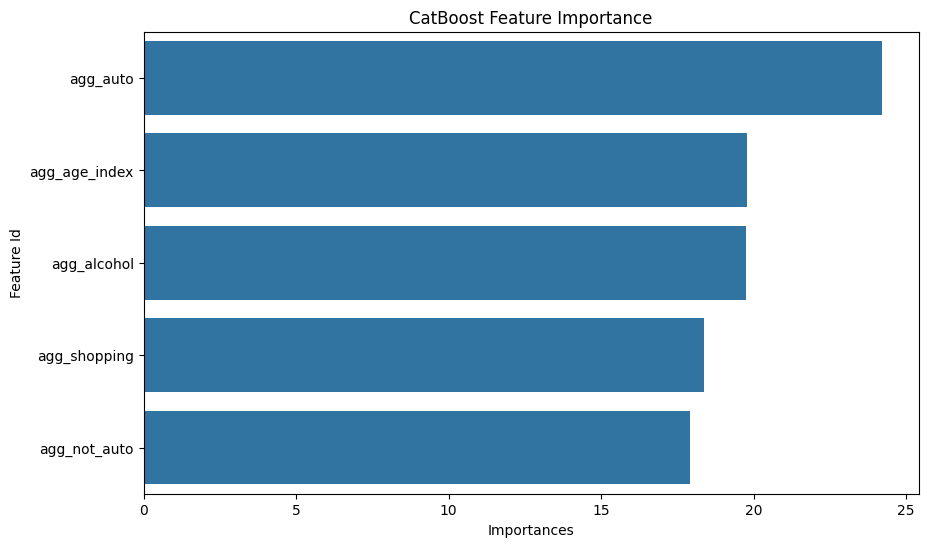

In [81]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split


X = aggregated_features 
y = casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, stratify=y, random_state=123)

model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.0001,
    depth=6,
    eval_metric='AUC',
    verbose=200 
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=500, 
    use_best_model=True
)

importances = model.get_feature_importance(prettified=True)
print("\nВажность признаков:")
print(importances)

importances = model.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importances", y="Feature Id", data=importances)
plt.title('CatBoost Feature Importance')
plt.show()


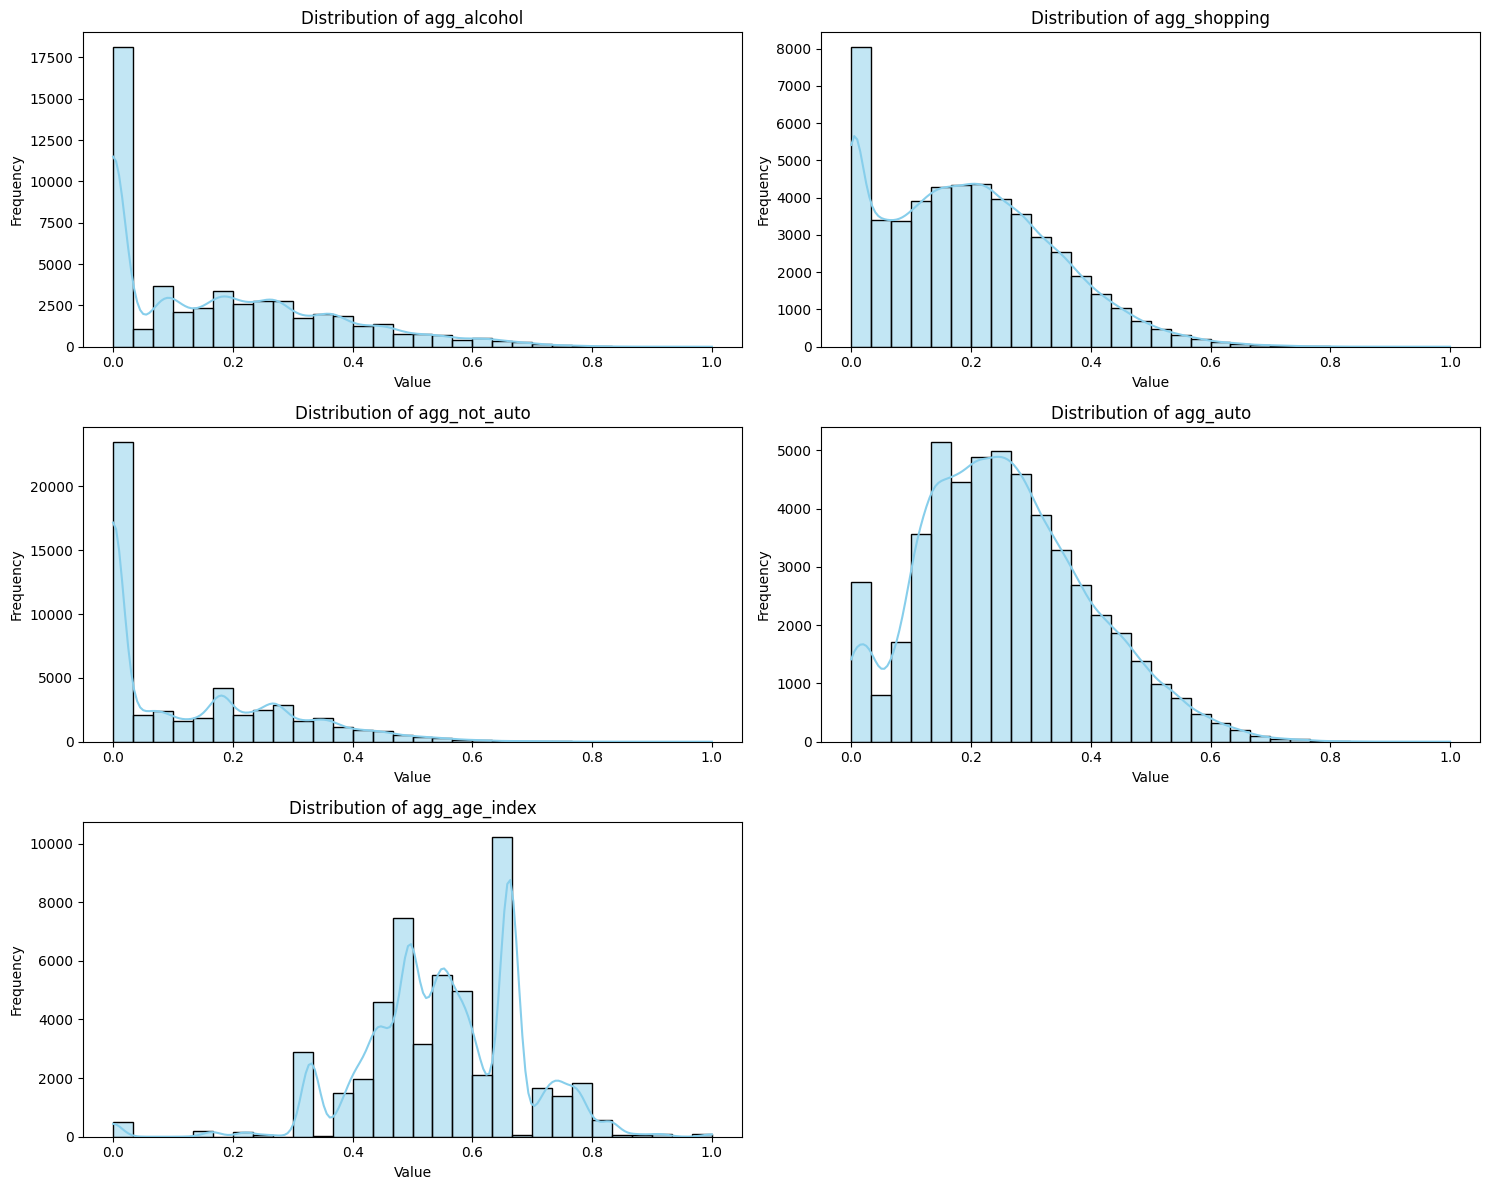

In [37]:
aggregated_features.describe()
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Предположим, что aggregated_features — это уже ваш DataFrame
# Пример: aggregated_features.head()

# Список признаков для визуализации
features = [
    'agg_alcohol', 'agg_shopping', 'agg_not_auto', 'agg_auto',
    'agg_age_index'
]

# Настройка фигуры: сетка 3x3 (хватит для 8 графиков)
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.histplot(aggregated_features[col].dropna(), kde=True, ax=ax, bins=30, color='skyblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# Удаление пустого подграфика (9-го, если всего 8 признаков)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# Noisy-OR агрегация (вероятность хотя бы одного)

p_i — это вероятность того, что у клиента есть конкретное поведение по тегу.
Агрегируем вероятность наличия хотя бы одного поведения в группе по формуле: `1 - П(1 - p_i)`.


In [8]:
import pandas as pd

class NoisyOrAggregator:
    def __init__(self, feature_dict, clip=True):
        self.feature_dict = feature_dict
        self.clip = clip

    def fit(self, X, y=None):
        # Для совместимости со sklearn-стилем
        return self

    def transform(self, df):
        """
        Агрегирует вероятности тегов внутри групп по формуле Noisy-OR: 1 - П(1 - p_i).
        df: исходный DataFrame
        feature_dict: словарь вида {'название_агрегата': [список_колонок]}
        clip: ограничить значения тегов в [0, 1]
        """
        res_df = pd.DataFrame(index=df.index) 

        for agg_name, cols in self.feature_dict.items():
            # Оставляем только реально существующие колонки
            cols_exist = [c for c in cols if c in df.columns]
            if not cols_exist:
                # Если в данных нет ни одного тега из группы - ставим 0
                res_df[f"{agg_name}_noisy_or"] = 0
                continue

            # Берем подматрицу значений тегов группы
            vals = df[cols_exist].copy()
            if self.clip:
                # Ограничиваем диапазон [0, 1]
                vals = vals.clip(lower=0, upper=1)
            # NaN считаем отсутствием сигнала
            vals = vals.fillna(0)

            # Noisy-OR: вероятность, что сработал хотя бы один тег
            res_df[f"{agg_name}_noisy_or"] = 1 - (1 - vals).prod(axis=1) 

        return res_df

# --- ПРИМЕР ИСПОЛЬЗОВАНИЯ ---

noisy_or_agg = NoisyOrAggregator(groups, clip=True)
noisy_or_features = noisy_or_agg.transform(casco_hashtags_full)
casco_hashtags_noisy_or = pd.concat([casco_hashtags_full, noisy_or_features], axis=1)